In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Варіант 8 — Полтава
CITY = "Poltava"
VARIANT = 8
LAMBDA = 0.16

# Теоретичне середнє експоненційного розподілу
TRUE_MEAN = 1 / LAMBDA

# Відтворюваність
rng = np.random.default_rng(VARIANT)

print("Variant:", VARIANT)
print("City:", CITY)
print("Lambda:", LAMBDA)
print("Theoretical mean:", TRUE_MEAN, "minutes")

Variant: 8
City: Poltava
Lambda: 0.16
Theoretical mean: 6.25 minutes


In [2]:
sample_sizes = [5, 50, 500, 20_000]

results_lln = []

for n in sample_sizes:
    sample = rng.exponential(
        scale=1 / LAMBDA,
        size=n
    )
    
    sample_mean = sample.mean()
    difference = abs(sample_mean - TRUE_MEAN)
    
    results_lln.append([
        n,
        sample_mean,
        difference
    ])

lln_table = pd.DataFrame(
    results_lln,
    columns=["n", "Sample mean", "Absolute difference"]
)

lln_table

,n,Sample mean,Absolute difference
0,5,8.030997,1.780997
1,50,5.357780,0.892220
2,500,6.033282,0.216718
3,20000,6.240011,0.009989


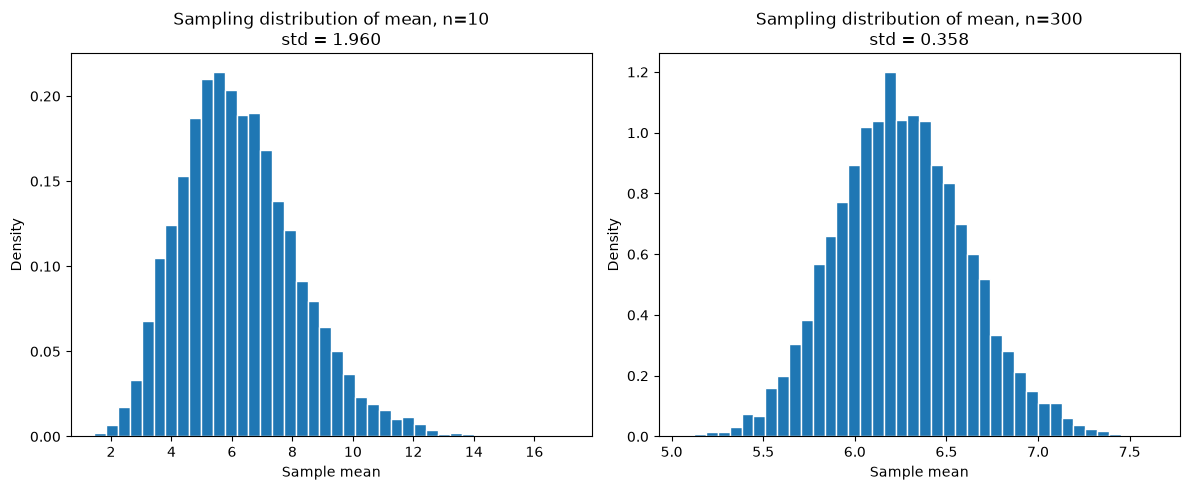

In [3]:
n_repeats = 10_000

sample_means_n10 = rng.exponential(
    scale=1 / LAMBDA,
    size=(n_repeats, 10)
).mean(axis=1)

sample_means_n300 = rng.exponential(
    scale=1 / LAMBDA,
    size=(n_repeats, 300)
).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(
    sample_means_n10,
    bins=40,
    density=True,
    edgecolor="white"
)
axes[0].set_title(
    f"Sampling distribution of mean, n=10\n"
    f"std = {sample_means_n10.std():.3f}"
)
axes[0].set_xlabel("Sample mean")
axes[0].set_ylabel("Density")

axes[1].hist(
    sample_means_n300,
    bins=40,
    density=True,
    edgecolor="white"
)
axes[1].set_title(
    f"Sampling distribution of mean, n=300\n"
    f"std = {sample_means_n300.std():.3f}"
)
axes[1].set_xlabel("Sample mean")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

In [4]:
n_values = [10, 30, 100, 300]
n_repeats = 10_000

se_results = []

for n in n_values:
    # Теоретична стандартна похибка
    se_theoretical = (1 / LAMBDA) / np.sqrt(n)
    
    # 10 000 повторних вибірок
    sample_means = rng.exponential(
        scale=1 / LAMBDA,
        size=(n_repeats, n)
    ).mean(axis=1)
    
    # Стандартне відхилення середніх із симуляції
    se_simulated = sample_means.std()
    
    se_results.append([
        n,
        se_theoretical,
        se_simulated
    ])

se_table = pd.DataFrame(
    se_results,
    columns=[
        "n",
        "Theoretical SE",
        "Simulated std"
    ]
)

se_table

,n,Theoretical SE,Simulated std
0,10,1.976424,1.956049
1,30,1.141089,1.132659
2,100,0.625000,0.613489
3,300,0.360844,0.361523


In [5]:
n_25 = 25
n_100 = 100

se_25 = (1 / LAMBDA) / np.sqrt(n_25)
se_100 = (1 / LAMBDA) / np.sqrt(n_100)

print("SE for n=25:", se_25)
print("SE for n=100:", se_100)
print("Ratio SE(25) / SE(100):", se_25 / se_100)

SE for n=25: 1.25
SE for n=100: 0.625
Ratio SE(25) / SE(100): 2.0


## Контрольні питання

### 1. Чим відрізняється закон великих чисел від центральної граничної теореми?

Закон великих чисел відповідає на питання, куди прямує вибіркове середнє x̄ зі збільшенням розміру вибірки. У цій практиці x̄ наближається до теоретичного середнього E[X] = 6.25 хвилини.

Центральна гранична теорема відповідає на інше питання: якою стає форма та розкид розподілу вибіркового середнього. При збільшенні n розподіл x̄ наближається до нормального.

### 2. Чому вихідний розподіл є сильно скошеним?

Експоненційний розподіл часу очікування є правосторонньо скошеним. Саме тому він добре демонструє роботу центральної граничної теореми.

Якби початкові дані вже мали нормальний розподіл, то розподіл вибіркового середнього також був би нормальним, і перехід до дзвоноподібної форми було б складніше продемонструвати наочно.

### 3. Чому стандартна похибка зменшується пропорційно √n?

Стандартна похибка середнього визначається формулою:

SE = σ / √n

Тому збільшення n у 4 рази зменшує SE у 2 рази. Щоб зменшити похибку вдвічі, потрібно зібрати в 4 рази більше спостережень. Це демонструє закон убуваючої віддачі: подальше зменшення похибки потребує дедалі більшого збільшення розміру вибірки.

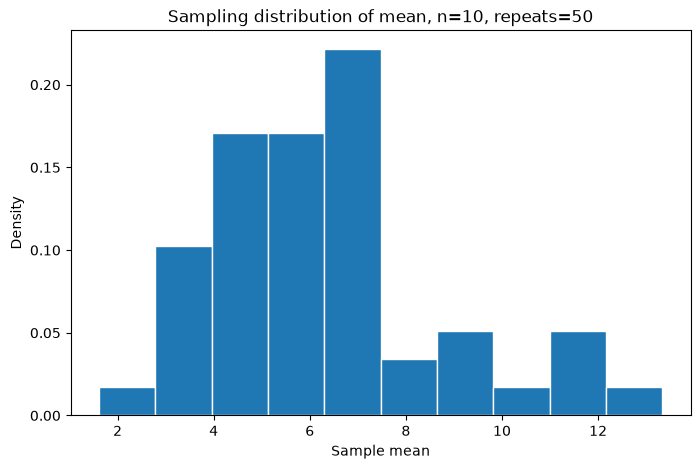

In [6]:
n = 10
n_repeats_small = 50

sample_means_50 = rng.exponential(
    scale=1 / LAMBDA,
    size=(n_repeats_small, n)
).mean(axis=1)

plt.figure(figsize=(8, 5))

plt.hist(
    sample_means_50,
    bins=10,
    density=True,
    edgecolor="white"
)

plt.xlabel("Sample mean")
plt.ylabel("Density")
plt.title("Sampling distribution of mean, n=10, repeats=50")

plt.show()

In [7]:
print("=== PRACTICE 11 RESULTS ===")
print("Variant:", VARIANT)
print("City:", CITY)
print("Lambda:", LAMBDA)
print("Theoretical mean:", TRUE_MEAN)
print()
print("SE values:")

for n in [10, 30, 100, 300]:
    se = (1 / LAMBDA) / np.sqrt(n)
    print(f"n={n}: SE={se:.4f}")

=== PRACTICE 11 RESULTS ===
Variant: 8
City: Poltava
Lambda: 0.16
Theoretical mean: 6.25

SE values:
n=10: SE=1.9764
n=30: SE=1.1411
n=100: SE=0.6250
n=300: SE=0.3608
